In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('Coastal Data System - Waves (Mooloolaba) 01-2017 to 06 - 2019.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst few rows:\n")
df.head()

Dataset shape: (43728, 7)

Columns:
['Date/Time', 'Hs', 'Hmax', 'Tz', 'Tp', 'Peak Direction', 'SST']

First few rows:



,Date/Time,Hs,Hmax,Tz,Tp,Peak Direction,SST
0,01/01/2017 00:00,-99.900,-99.90,-99.900,-99.900,-99.9,-99.90
1,01/01/2017 00:30,0.875,1.39,4.421,4.506,-99.9,-99.90
2,01/01/2017 01:00,0.763,1.15,4.520,5.513,49.0,25.65
3,01/01/2017 01:30,0.770,1.41,4.582,5.647,75.0,25.50
4,01/01/2017 02:00,0.747,1.16,4.515,5.083,91.0,25.45


In [2]:
# Replace -99.9 with NaN (missing data)
df = df.replace(-99.9, np.nan)

# Convert Date/Time to proper datetime format
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Drop rows with missing wave height
df = df.dropna(subset=['Hs', 'Tp'])

print(f"Clean dataset: {df.shape[0]} readings")
print(f"\nBasic stats:")
print(df[['Hs', 'Hmax', 'Tp', 'Peak Direction']].describe().round(2))

ValueError: time data "13/01/2019 00:00" doesn't match format "%m/%d/%Y %H:%M", at position 35616. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [3]:
# Replace -99.9 with NaN (missing data)
df = df.replace(-99.9, np.nan)

# Convert Date/Time with dayfirst=True
df['Date/Time'] = pd.to_datetime(df['Date/Time'], dayfirst=True)

# Drop rows with missing wave height
df = df.dropna(subset=['Hs', 'Tp'])

print(f"Clean dataset: {df.shape[0]} readings")
print(f"\nBasic stats:")
print(df[['Hs', 'Hmax', 'Tp', 'Peak Direction']].describe().round(2))

ValueError: time data "1/13/2017 0:00" doesn't match format "%d/%m/%Y %H:%M", at position 576. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [4]:
# Replace -99.9 with NaN (missing data)
df = df.replace(-99.9, np.nan)

# Convert Date/Time with mixed format
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='mixed', dayfirst=True)

# Drop rows with missing wave height
df = df.dropna(subset=['Hs', 'Tp'])

print(f"Clean dataset: {df.shape[0]} readings")
print(f"\nBasic stats:")
print(df[['Hs', 'Hmax', 'Tp', 'Peak Direction']].describe().round(2))

Clean dataset: 43643 readings

Basic stats:
             Hs      Hmax        Tp  Peak Direction
count  43643.00  43643.00  43643.00        43454.00
mean       1.24      2.09      9.01           98.63
std        0.53      0.90      2.39           24.28
min        0.29      0.51      2.72            5.00
25%        0.84      1.41      7.29           85.00
50%        1.13      1.90      8.88          101.00
75%        1.54      2.60     10.67          116.00
max        4.26      7.91     21.12          358.00


In [5]:
# Surf condition classifier based on real surfer criteria
def classify_conditions(row):
    hs = row['Hs']      # wave height in meters
    tp = row['Tp']      # peak period in seconds
    
    # Too small or too big
    if hs < 0.5:
        return 'Flat - Skip'
    if hs > 3.5:
        return 'Dangerous - Expert Only'
    
    # Period quality check
    if tp < 7:
        return 'Choppy - Skip'
    
    # Good conditions
    if hs >= 1.0 and tp >= 10:
        return 'Epic - Go Surf!'
    if hs >= 0.7 and tp >= 8:
        return 'Good - Worth It'
    
    return 'Average - If Nothing Else'

df['Surf Rating'] = df.apply(classify_conditions, axis=1)

print(df['Surf Rating'].value_counts())
print(f"\nPercentage breakdown:")
print((df['Surf Rating'].value_counts() / len(df) * 100).round(1))

Surf Rating
Good - Worth It              16358
Average - If Nothing Else    10112
Choppy - Skip                 8766
Epic - Go Surf!               7383
Flat - Skip                    984
Dangerous - Expert Only         40
Name: count, dtype: int64

Percentage breakdown:
Surf Rating
Good - Worth It              37.5
Average - If Nothing Else    23.2
Choppy - Skip                20.1
Epic - Go Surf!              16.9
Flat - Skip                   2.3
Dangerous - Expert Only       0.1
Name: count, dtype: float64


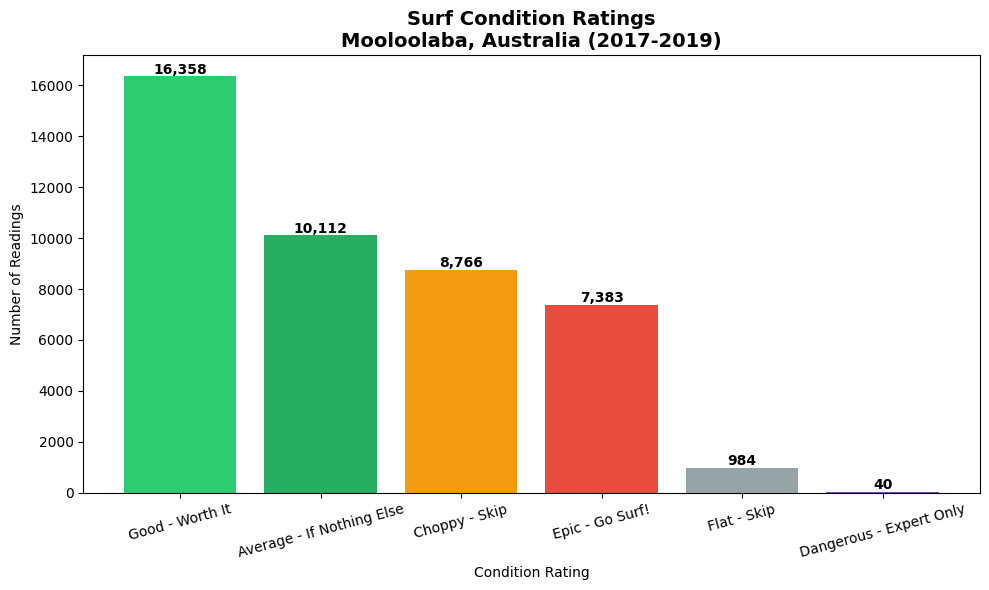

In [6]:
# Surf Rating Distribution
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#95a5a6', '#8e44ad']
rating_counts = df['Surf Rating'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.title('Surf Condition Ratings\nMooloolaba, Australia (2017-2019)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Condition Rating')
plt.ylabel('Number of Readings')
plt.xticks(rotation=15)
for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

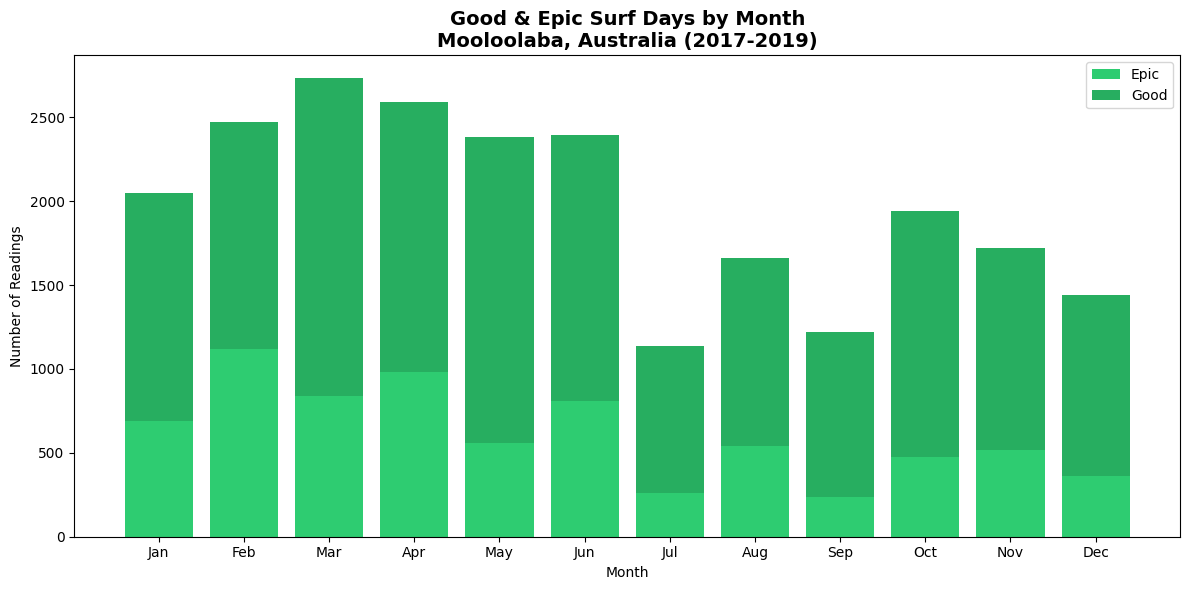

In [7]:
# Extract month from date
df['Month'] = df['Date/Time'].dt.month
df['Month Name'] = df['Date/Time'].dt.strftime('%b')

# Epic days by month
epic_by_month = df[df['Surf Rating'] == 'Epic - Go Surf!'].groupby('Month').size()
good_by_month = df[df['Surf Rating'] == 'Good - Worth It'].groupby('Month').size()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.bar(month_names, epic_by_month.reindex(range(1,13), fill_value=0), 
        label='Epic', color='#2ecc71')
plt.bar(month_names, good_by_month.reindex(range(1,13), fill_value=0),
        bottom=epic_by_month.reindex(range(1,13), fill_value=0),
        label='Good', color='#27ae60')
plt.title('Good & Epic Surf Days by Month\nMooloolaba, Australia (2017-2019)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Readings')
plt.legend()
plt.tight_layout()
plt.show()

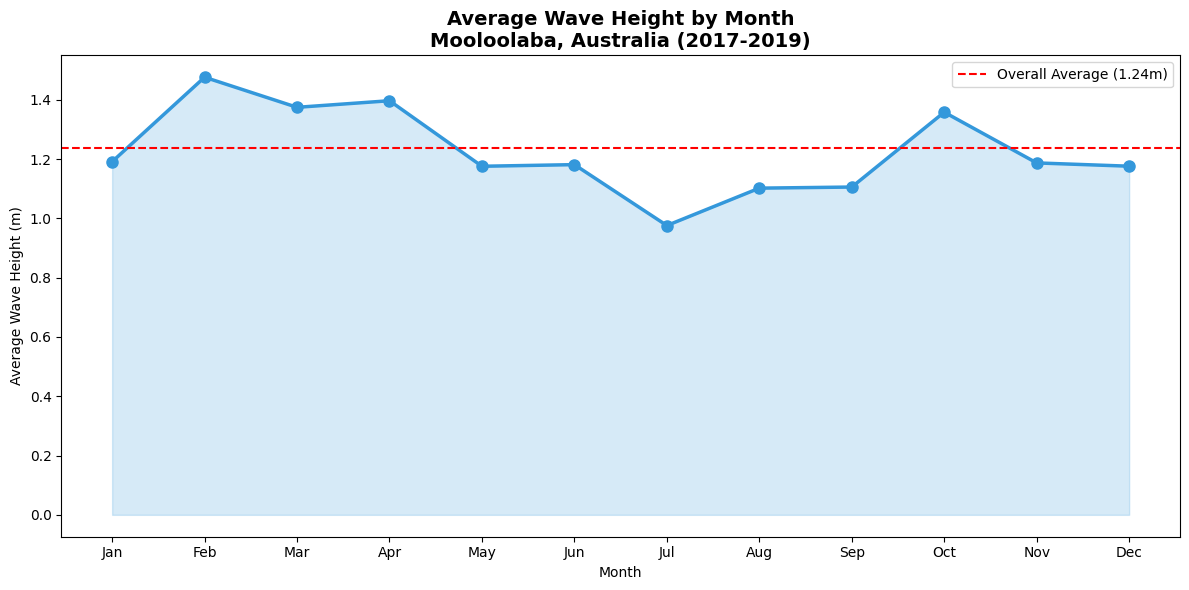

In [8]:
# Average wave height by month
avg_hs_by_month = df.groupby('Month')['Hs'].mean()

plt.figure(figsize=(12, 6))
plt.plot(month_names, avg_hs_by_month.reindex(range(1,13)), 
         color='#3498db', linewidth=2.5, marker='o', markersize=8)
plt.fill_between(month_names, 
                 avg_hs_by_month.reindex(range(1,13)),
                 alpha=0.2, color='#3498db')
plt.title('Average Wave Height by Month\nMooloolaba, Australia (2017-2019)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Wave Height (m)')
plt.axhline(y=df['Hs'].mean(), color='red', linestyle='--', 
            label=f'Overall Average ({df["Hs"].mean():.2f}m)')
plt.legend()
plt.tight_layout()
plt.show()

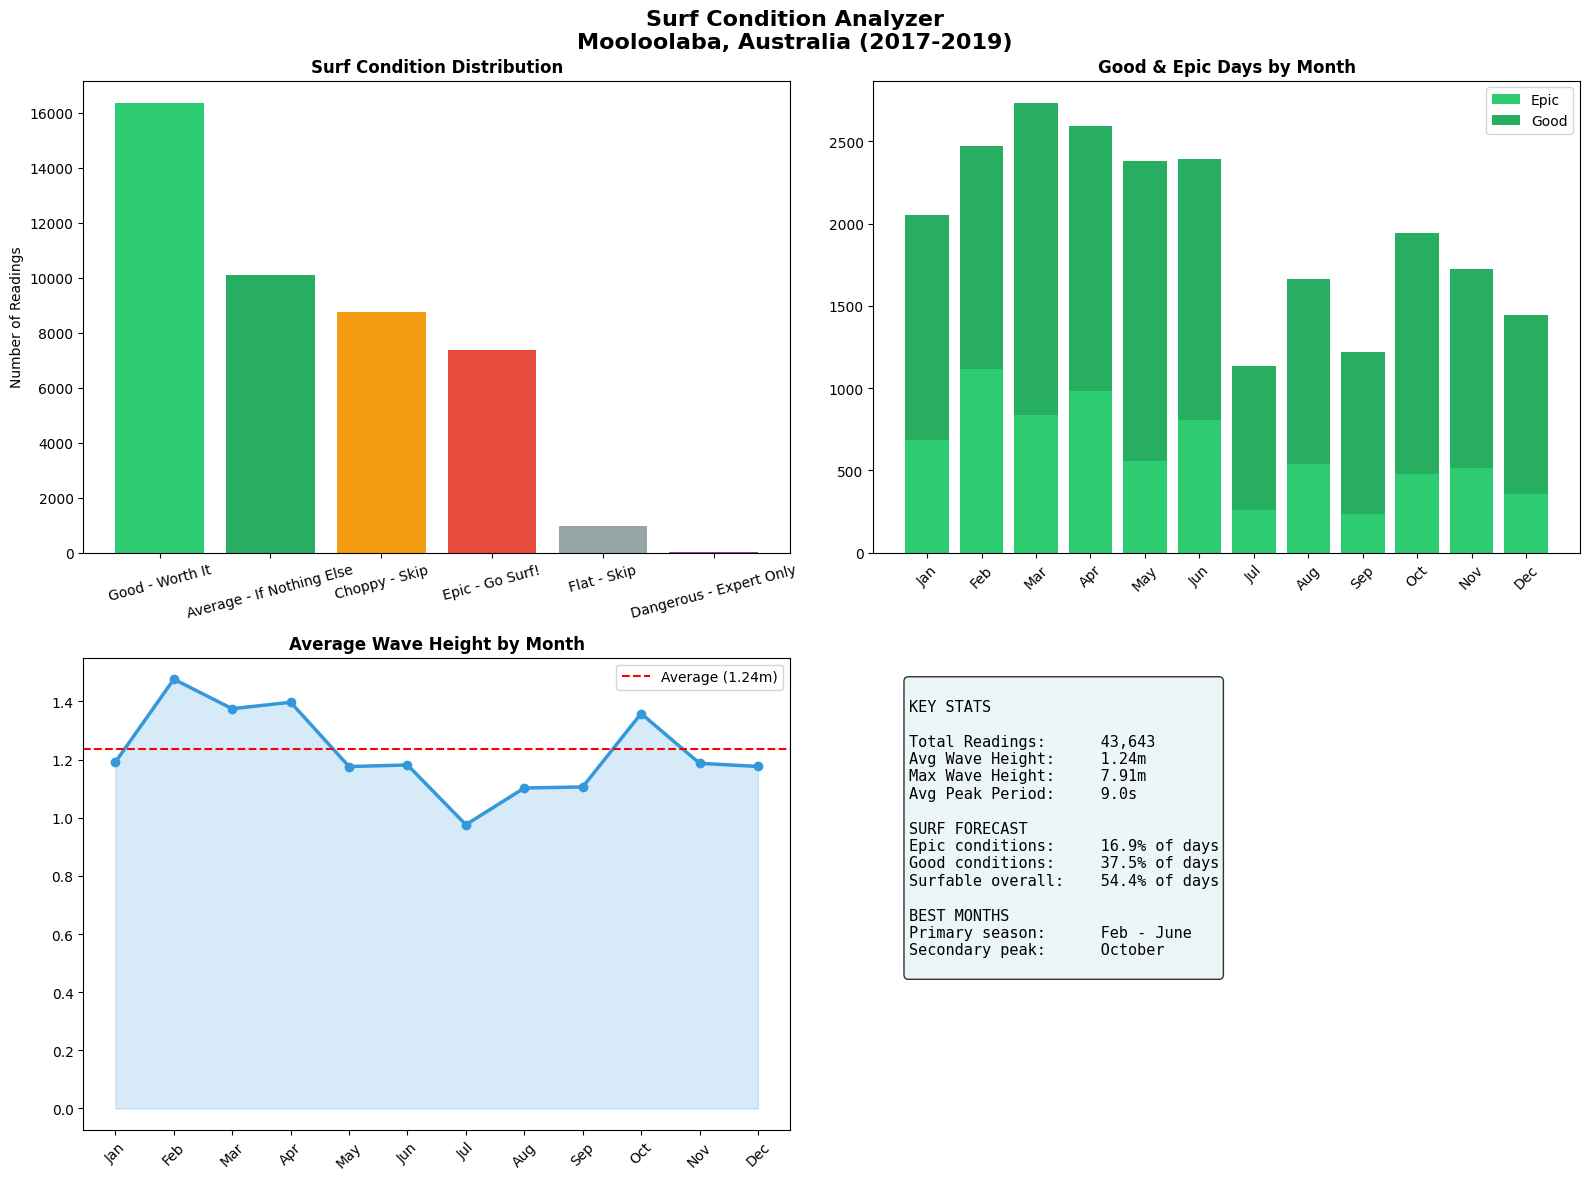

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Surf Condition Analyzer\nMooloolaba, Australia (2017-2019)', 
             fontsize=16, fontweight='bold')

# Chart 1 - Surf Ratings
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#95a5a6', '#8e44ad']
rating_counts = df['Surf Rating'].value_counts()
axes[0, 0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0, 0].set_title('Surf Condition Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Number of Readings')
axes[0, 0].tick_params(axis='x', rotation=15)

# Chart 2 - Good & Epic by Month
epic_by_month = df[df['Surf Rating'] == 'Epic - Go Surf!'].groupby('Month').size()
good_by_month = df[df['Surf Rating'] == 'Good - Worth It'].groupby('Month').size()
axes[0, 1].bar(month_names, epic_by_month.reindex(range(1,13), fill_value=0),
               label='Epic', color='#2ecc71')
axes[0, 1].bar(month_names, good_by_month.reindex(range(1,13), fill_value=0),
               bottom=epic_by_month.reindex(range(1,13), fill_value=0),
               label='Good', color='#27ae60')
axes[0, 1].set_title('Good & Epic Days by Month', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Chart 3 - Average Wave Height by Month
avg_hs = df.groupby('Month')['Hs'].mean()
axes[1, 0].plot(month_names, avg_hs.reindex(range(1,13)),
                color='#3498db', linewidth=2.5, marker='o')
axes[1, 0].fill_between(month_names, avg_hs.reindex(range(1,13)),
                        alpha=0.2, color='#3498db')
axes[1, 0].axhline(y=df['Hs'].mean(), color='red', linestyle='--',
                   label=f'Average ({df["Hs"].mean():.2f}m)')
axes[1, 0].set_title('Average Wave Height by Month', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# KPIs box
axes[1, 1].axis('off')
epic_pct = (df['Surf Rating'] == 'Epic - Go Surf!').sum() / len(df) * 100
good_pct = (df['Surf Rating'] == 'Good - Worth It').sum() / len(df) * 100
kpi_text = f"""
KEY STATS

Total Readings:      {len(df):,}
Avg Wave Height:     {df['Hs'].mean():.2f}m
Max Wave Height:     {df['Hmax'].max():.2f}m
Avg Peak Period:     {df['Tp'].mean():.1f}s

SURF FORECAST
Epic conditions:     {epic_pct:.1f}% of days
Good conditions:     {good_pct:.1f}% of days
Surfable overall:    {epic_pct+good_pct:.1f}% of days

BEST MONTHS
Primary season:      Feb - June
Secondary peak:      October
"""
axes[1, 1].text(0.05, 0.95, kpi_text, fontsize=11, verticalalignment='top',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#e8f4f8', alpha=0.8))

plt.tight_layout()
plt.savefig('surf_condition_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()